In [16]:
#  Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_excel("extracted_laptop_features_cleaned.xlsx")


In [18]:
df.fillna("Unknown", inplace=True)

C:\Users\purva\AppData\Local\Temp\ipykernel_19688\839676283.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


In [19]:
df['Display_Size_Inch'] = pd.to_numeric(df['Display_Size_Inch'], errors='coerce').fillna(0)

# Convert storage size to GB
def convert_to_gb(val):
    if isinstance(val, str) and "GB" in val:
        try:
            return int(val.split()[0])
        except:
            return 0
    return 0

df['SSD_Size_GB'] = df['SSD_Size'].apply(convert_to_gb)
df['HDD_Size_GB'] = df['HDD_Size'].apply(convert_to_gb)
df['eMMC_Size_GB'] = df['eMMC_Size'].apply(convert_to_gb)

In [ ]:
df['Total_Storage_GB'] = df['SSD_Size_GB'] + df['HDD_Size_GB'] + df['eMMC_Size_GB']

In [21]:
label_cols = ['Processor_Model', 'RAM', 'Operating_System', 'Graphics_Name', 'Warranty']
le_dict = {}

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [22]:
df.drop(columns=['SSD_Size', 'HDD_Size', 'eMMC_Size'], inplace=True)


In [ ]:
features = ['Processor_Model', 'RAM', 'Operating_System', 'Graphics_Name',
            'Display_Size_Inch', 'Total_Storage_GB', 'Warranty']
X = df[features]
Y = df['MRP']

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=44)


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=100,         
    max_depth=None,           
    n_jobs=-1,
    #random_state=44                  
)
rf_model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
Y_pred_rf = rf_model.predict(X_test)


In [27]:
mse = mean_squared_error(Y_test, Y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred_rf)

print("\n Random Forest Evaluation Metrics:")
print(f" MSE:  {mse:.2f}")
print(f" RMSE: {rmse:.2f}")
print(f" R² Score: {r2:.2f}")


 Random Forest Evaluation Metrics:
 MSE:  250979758.71
 RMSE: 15842.34
 R² Score: 0.93


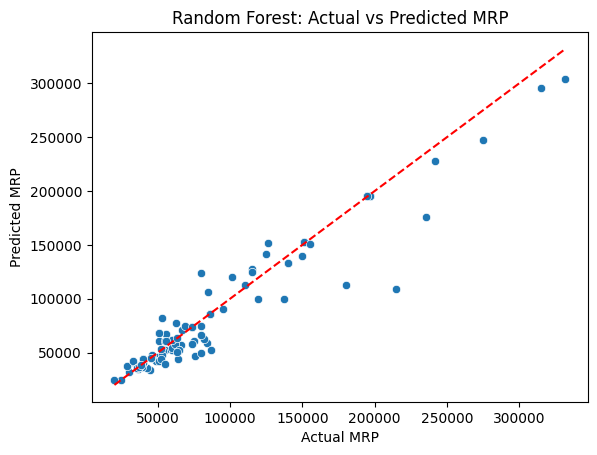

In [28]:
sns.scatterplot(x=Y_test, y=Y_pred_rf)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel("Actual MRP")
plt.ylabel("Predicted MRP")
plt.title("Random Forest: Actual vs Predicted MRP")
plt.show()

In [29]:
import numpy as np
import pandas as pd

df = pd.read_excel("extracted_laptop_features_cleaned.xlsx")

# Calculate variance of MRP column
variance = np.var(df['MRP'])
print("Variance of MRP:", variance)

Variance of MRP: 3783504106.45276


In [30]:
std_dev = np.std(df['MRP'])
print("Standard Deviation of MRP:", std_dev)




Standard Deviation of MRP: 61510.19514237262


In [ ]:
# laptop 3 
import numpy as np
import pandas as pd

df = pd.read_excel("extracted_laptop_features_cleaned.xlsx")

# Calculate variance of MRP column
variance = np.var(df['MRP'])
print("Variance of MRP:", variance)